In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.ndimage import binary_erosion
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize

os.makedirs("figures", exist_ok=True)

**Parameters**

In [28]:
N = 128                                                # image size (N x N)
THETA = np.linspace(0., 180., 180, endpoint=False)     # projection angles, 1° steps
FILTERS = ["ramp", "shepp-logan", "cosine", "hamming", "hann"]   # Step 3
COUNT_LEVELS = [1e4, 1e5, 1e6]                         # total counts
FBP_CUTOFFS = [0.1, 0.15, 0.25, 0.35, 0.5, 0.75, 1.0]  # Hann cut-off, × Nyquist
MLEM_ITERS = [2, 3, 5, 7, 10, 15, 20, 30, 50, 100]     # MLEM iterations recorded
N_ITER = MLEM_ITERS[-1]
N_REAL = 10                                            # noise realisations per setting
SEED = 0

**Functions**

Phantom, projectors and noise

In [29]:
yy, xx = np.mgrid[:N, :N] - N // 2
FOV = xx**2 + yy**2 <= (N // 2) ** 2                   # circular field of view assumed by radon


def forward(x):
  """A: image -> sinogram."""
  return radon(x, theta=THETA, circle=True)


def backproject(y):
  """A^T up to a constant factor: unfiltered backprojection."""
  return iradon(y, theta=THETA, filter_name=None, circle=True, output_size=N)


def make_phantom():
  img = resize(shepp_logan_phantom(), (N, N))
  img[~FOV] = 0
  return img


def add_poisson_noise(sino, counts, rng):
  """Scale `sino` to `counts` total events and draw Poisson noise.
  Returns (y in counts, k); divide by k to return to phantom units."""
  k = counts / sino.sum()
  return rng.poisson(sino * k).astype(float), k


def realisation_rng(count_index, r):
  """Independent, reproducible random stream for noise realisation r at a count level."""
  return np.random.default_rng([SEED, count_index, r])

Regions of interest and metrics

In [30]:
def make_rois(erode=3):
  """hot: large 0.3 ellipse (upper half); bkg: uniform 0.2 region. Both eroded by `erode` px."""
  lab = np.round(resize(shepp_logan_phantom(), (N, N), order=0, anti_aliasing=False), 1)
  hot = (lab == 0.3) & (np.arange(N)[:, None] < N // 2)
  bkg = lab == 0.2
  st = np.ones((3, 3), bool)
  return binary_erosion(hot, st, iterations=erode), binary_erosion(bkg, st, iterations=erode)


def nrmse(recon, truth):
  """RMSE / RMS(truth) inside the field of view."""
  return np.sqrt(np.mean((recon[FOV] - truth[FOV]) ** 2) / np.mean(truth[FOV] ** 2))


def evaluate(recon, truth, hot, bkg):
  contrast = lambda img: img[hot].mean() / img[bkg].mean() - 1
  return {"NRMSE": nrmse(recon, truth),
            "CR": contrast(recon) / contrast(truth),
            "SD_bkg": recon[bkg].std()}

Reconstruction

In [32]:
def fbp(sino, filter_name):
  """FBP with one of skimage's built-in filters."""
  img = iradon(sino, theta=THETA, filter_name=filter_name, circle=True, output_size=N)
  return np.where(FOV, img, 0)


def fbp_cutoff(sino, cutoff=None):
  """FBP with a ramp filter times a Hann window cut off at `cutoff` × Nyquist.
  Ramp built in the spatial domain and zero-padding as in skimage, so
  cutoff=None reproduces fbp(sino, "ramp")."""
  n = sino.shape[0]
  diag = int(np.ceil(np.sqrt(2) * n))
  before = diag // 2 - n // 2
  size = max(64, int(2 ** np.ceil(np.log2(2 * diag))))
  h = np.zeros(size)                                   # spatial-domain ramp (Kak & Slaney)
  h[0] = 0.25
  odd = np.concatenate((np.arange(1, size / 2 + 1, 2), np.arange(size / 2 - 1, 0, -2)))
  h[1::2] = -1 / (np.pi * odd) ** 2
  H = 2 * np.real(np.fft.fft(h))
  if cutoff is not None:
    nu = np.abs(np.fft.fftfreq(size)) * 2            # 1 = Nyquist
    H *= np.where(nu <= cutoff, 0.5 * (1 + np.cos(np.pi * nu / cutoff)), 0)
  padded = np.pad(sino, ((before, size - n - before), (0, 0)))
  filtered = np.real(np.fft.ifft(np.fft.fft(padded, axis=0) * H[:, None], axis=0))[:diag]
  img = iradon(filtered, theta=THETA, filter_name=None, circle=False, output_size=N)
  return np.where(FOV, img, 0)


def mlem(y, n_iter):
  """x <- x / A^T1 * A^T(y / Ax). Returns images after each iteration and the
  Poisson log-likelihood of the image entering each iteration."""
  sens = backproject(np.ones_like(y))
  x = FOV.astype(float)
  images, loglik = [], []
  for _ in range(n_iter):
    y_est = forward(x)
    loglik.append(np.sum(y * np.log(np.maximum(y_est, 1e-12)) - y_est))
    ratio = np.divide(y, y_est, out=np.zeros_like(y), where=y_est > 0)
    x = np.where(FOV, x * backproject(ratio) / np.where(sens > 0, sens, 1), 0)
    images.append(x)
  return images, np.array(loglik)

**Main**

Step1. Phantom and sinogram


Phantom (128, 128), sinogram (128, 180) (detector bins x angles)


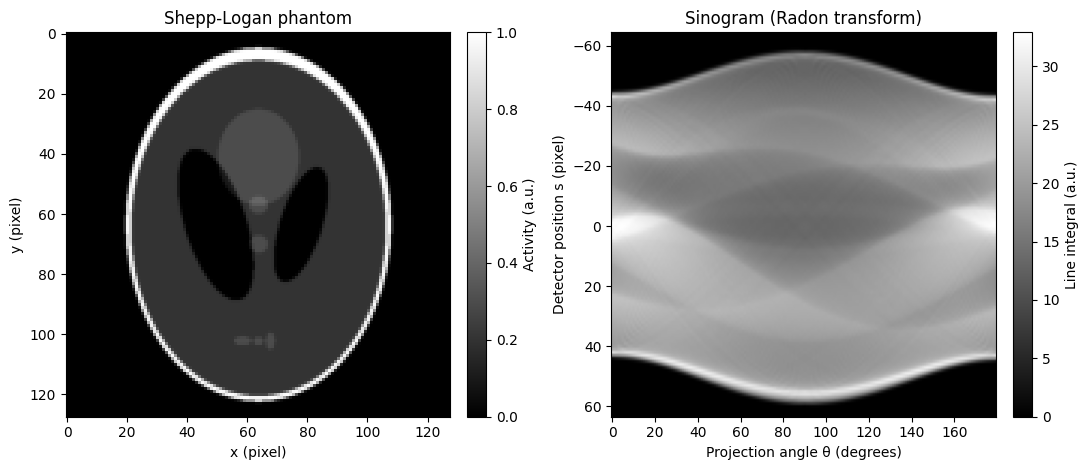

In [33]:
phantom = make_phantom()
sino_clean = forward(phantom)
print(f"Phantom {phantom.shape}, sinogram {sino_clean.shape} (detector bins x angles)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.8))
fig.colorbar(a1.imshow(phantom, cmap="gray"), ax=a1, fraction=0.046, pad=0.04, label="Activity (a.u.)")
a1.set(title="Shepp-Logan phantom", xlabel="x (pixel)", ylabel="y (pixel)")
d = THETA[1] - THETA[0]
im = a2.imshow(sino_clean, cmap="gray", aspect="auto",                 # extent = pixel edges
        extent=(THETA[0] - d / 2, THETA[-1] + d / 2, N // 2 - 0.5, -N // 2 - 0.5))
fig.colorbar(im, ax=a2, fraction=0.046, pad=0.04, label="Line integral (a.u.)")
a2.set(title="Sinogram (Radon transform)", xlabel="Projection angle θ (degrees)",
  ylabel="Detector position s (pixel)")
plt.tight_layout(); plt.savefig("figures/phantom_sinogram.png", dpi=150); plt.show()

Step 2. Regions of interest

In [34]:
hot, bkg = make_rois()
print(f"Hot ROI {hot.sum()} px (mean {phantom[hot].mean():.3f}), "
  f"uniform ROI {bkg.sum()} px (mean {phantom[bkg].mean():.3f})")

Hot ROI 330 px (mean 0.298), uniform ROI 3183 px (mean 0.200)


Step 3. FBP with skimage's filters, noise-free data

,NRMSE,CR,SD_bkg
ramp,0.1364,1.0010,0.0029
shepp-logan,0.1585,1.0008,0.0022
cosine,0.2027,1.0006,0.0012
hamming,0.2382,1.0006,0.0009
hann,0.2474,1.0006,0.0008


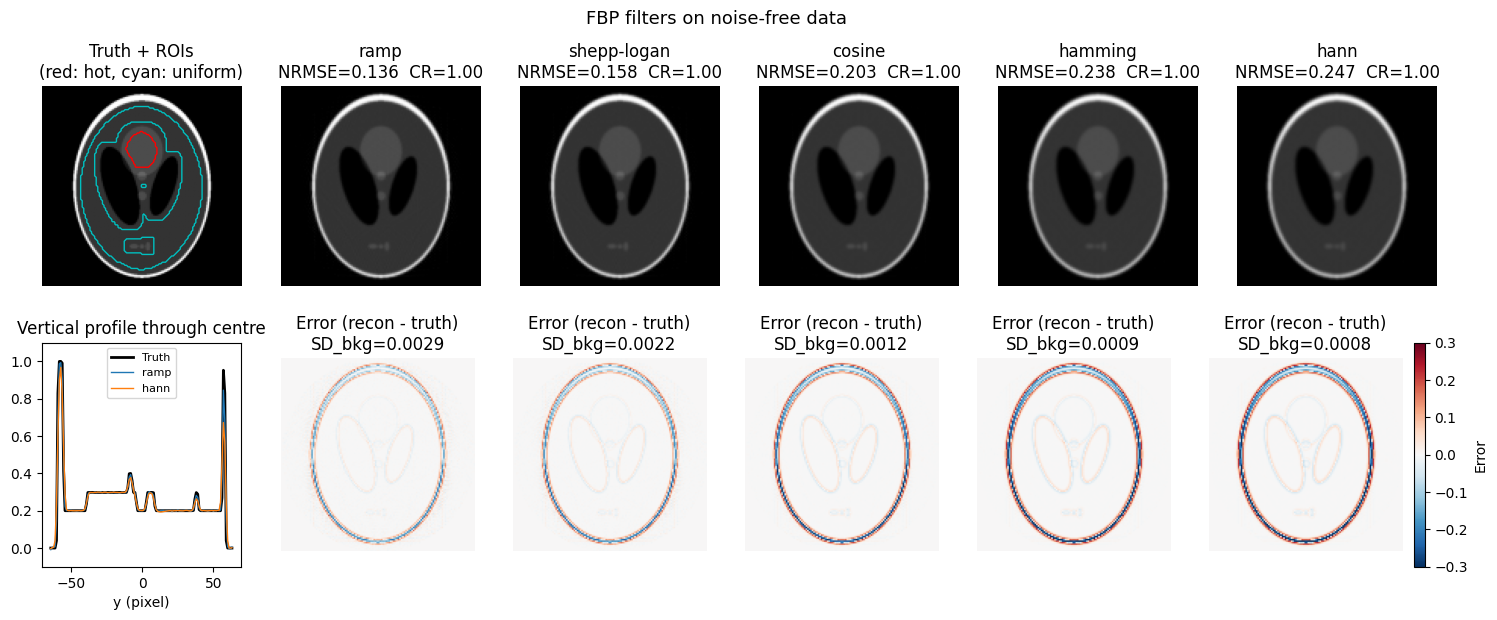

In [35]:
recons = {f: fbp(sino_clean, f) for f in FILTERS}
results = pd.DataFrame({f: evaluate(r, phantom, hot, bkg) for f, r in recons.items()}).T
display(results.round(4))

fig, ax = plt.subplots(2, 6, figsize=(18, 6.4))
ax[0, 0].imshow(phantom, cmap="gray", vmin=0, vmax=1)
ax[0, 0].contour(hot, [0.5], colors="r", linewidths=1)
ax[0, 0].contour(bkg, [0.5], colors="c", linewidths=1)
ax[0, 0].set_title("Truth + ROIs\n(red: hot, cyan: uniform)")
s = np.arange(N) - N // 2
ax[1, 0].plot(s, phantom[:, N // 2], "k", lw=2, label="Truth")
for f in ["ramp", "hann"]:
  ax[1, 0].plot(s, recons[f][:, N // 2], lw=1, label=f)
ax[1, 0].set(title="Vertical profile through centre", xlabel="y (pixel)", ylim=(-0.1, 1.1))
ax[1, 0].legend(fontsize=8)
for j, f in enumerate(FILTERS, start=1):
  ax[0, j].imshow(recons[f], cmap="gray", vmin=0, vmax=1)
  ax[0, j].set_title(f"{f}\nNRMSE={results.loc[f, 'NRMSE']:.3f}  CR={results.loc[f, 'CR']:.2f}")
  im = ax[1, j].imshow(recons[f] - phantom, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
  ax[1, j].set_title(f"Error (recon - truth)\nSD_bkg={results.loc[f, 'SD_bkg']:.4f}")
for a in ax.flat:
  if a is not ax[1, 0]:
    a.axis("off")
fig.colorbar(im, ax=ax[1, 1:].tolist(), fraction=0.02, pad=0.01, label="Error")
fig.suptitle("FBP filters on noise-free data", fontsize=13)
plt.savefig("figures/fbp_filters_noisefree.png", dpi=110, bbox_inches="tight"); plt.show()

Step4. Poisson noise at 10^4, 10^5 and 10^6 counts

1e+04 counts: mean per bin   0.44, max    5, zero bins 66.2%
1e+05 counts: mean per bin   4.33, max   19, zero bins 19.3%
1e+06 counts: mean per bin  43.39, max  114, zero bins 17.7%


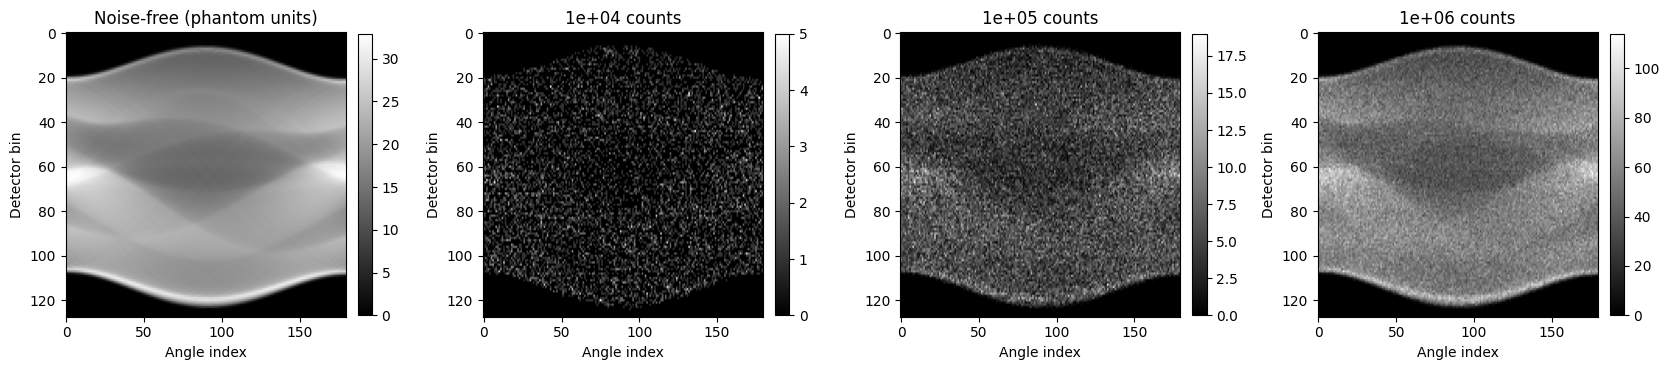

In [36]:
fig, ax = plt.subplots(1, 1 + len(COUNT_LEVELS), figsize=(16.8, 3.8))
panels = [("Noise-free (phantom units)", sino_clean)]
for ci, c in enumerate(COUNT_LEVELS):
  y, _ = add_poisson_noise(sino_clean, c, realisation_rng(ci, 0))
  print(f"{c:.0e} counts: mean per bin {y.mean():6.2f}, max {y.max():4.0f}, "
    f"zero bins {100 * (y == 0).mean():4.1f}%")
  panels.append((f"{c:.0e} counts", y))
for a, (t, img) in zip(ax, panels):
  fig.colorbar(a.imshow(img, cmap="gray", aspect="auto"), ax=a, fraction=0.046, pad=0.04)
  a.set(title=t, xlabel="Angle index", ylabel="Detector bin")
plt.tight_layout(); plt.savefig("figures/noisy_sinograms.png", dpi=110); plt.show()

Step 5. MLEM: validation on noise free data

Adjoint test, expected constant 2*n_angles/pi = 114.592
  draw 1: <Ax, y> / <x, A^T y> = 114.543
  draw 2: <Ax, y> / <x, A^T y> = 114.548
  draw 3: <Ax, y> / <x, A^T y> = 114.544
PASS: NRMSE 0.728 -> 0.062 and log-likelihood rise monotonically over 100 iterations


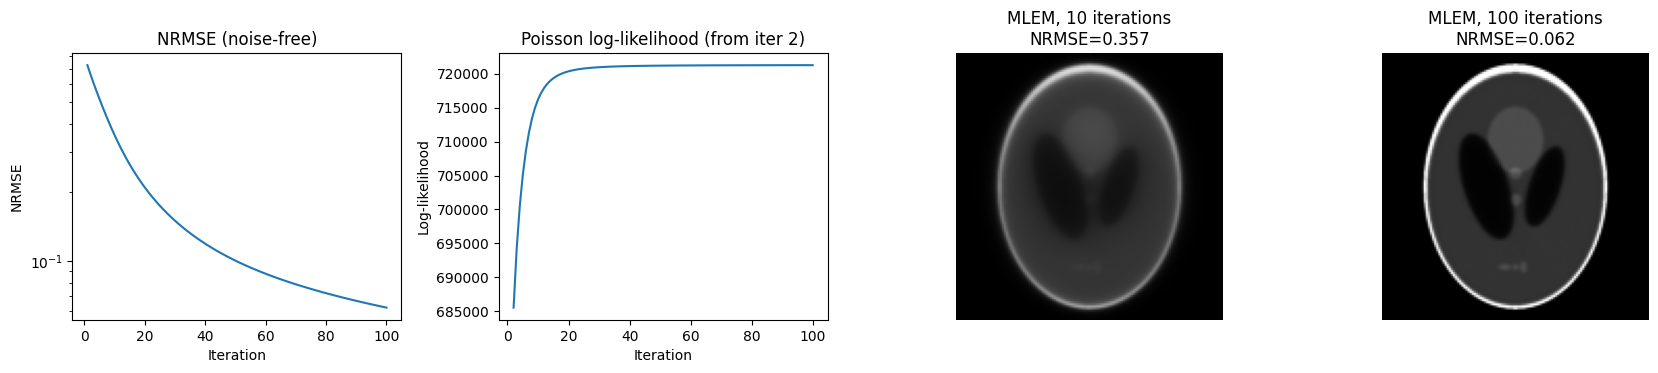

In [37]:
rng = np.random.default_rng(1)
print(f"Adjoint test, expected constant 2*n_angles/pi = {2 * len(THETA) / np.pi:.3f}")
for i in range(3):
  xr, yr = rng.random((N, N)) * FOV, rng.random((N, len(THETA)))
  print(f"  draw {i + 1}: <Ax, y> / <x, A^T y> = "
    f"{np.vdot(forward(xr), yr) / np.vdot(xr, backproject(yr)):.3f}")

imgs_clean, ll_clean = mlem(sino_clean, N_ITER)
err_clean = np.array([nrmse(x, phantom) for x in imgs_clean])
assert (np.diff(err_clean) <= 0).all() and (np.diff(ll_clean) >= 0).all(), \
  "MLEM is not monotone on noise-free data: bug"
print(f"PASS: NRMSE {err_clean[0]:.3f} -> {err_clean[-1]:.3f} and log-likelihood "
  f"rise monotonically over {N_ITER} iterations")

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
it = np.arange(1, N_ITER + 1)
ax[0].semilogy(it, err_clean)
ax[0].set(xlabel="Iteration", ylabel="NRMSE", title="NRMSE (noise-free)")
ax[1].plot(it[1:], ll_clean[1:])                        # skip the uniform start image
ax[1].set(xlabel="Iteration", ylabel="Log-likelihood", title="Poisson log-likelihood (from iter 2)")
for a, j in zip(ax[2:], [9, N_ITER - 1]):
  a.imshow(imgs_clean[j], cmap="gray", vmin=0, vmax=1)
  a.set_title(f"MLEM, {j + 1} iterations\nNRMSE={err_clean[j]:.3f}"); a.axis("off")
plt.tight_layout(); plt.savefig("figures/mlem_noisefree.png", dpi=110); plt.show()

### Step 6. Systematic experiment: counts × method × parameter, 10 noise realisations

In [38]:
ref = fbp(sino_clean, "ramp")
diff = np.abs(fbp_cutoff(sino_clean) - ref).max() / ref.max()
assert diff < 1e-10, "fbp_cutoff does not reproduce skimage's ramp FBP"
print(f"fbp_cutoff(None) vs skimage ramp: max relative difference {diff:.1e}")

fbp_cutoff(None) vs skimage ramp: max relative difference 2.5e-15


In [39]:
rows, recon0 = [], {}                     # recon0: images from realisation 0, for the figure
for ci, c in enumerate(COUNT_LEVELS):
  for r in range(N_REAL):
    y, k = add_poisson_noise(sino_clean, c, realisation_rng(ci, r))   # same data for both methods
    imgs, _ = mlem(y, N_ITER)
    settings = [("FBP", fc, fbp_cutoff(y / k, fc)) for fc in FBP_CUTOFFS] + \
          [("MLEM", it, imgs[it - 1] / k) for it in MLEM_ITERS]
    for method, p, img in settings:
      rows.append(dict(counts=c, real=r, method=method, param=p,
              **evaluate(img, phantom, hot, bkg)))
      if r == 0:
        recon0[(c, method, p)] = img
  print(f"{c:.0e} counts done")
df = pd.DataFrame(rows)

1e+04 counts done
1e+05 counts done
1e+06 counts done


Result, including mean and sd.

In [40]:
summary = df.groupby(["counts", "method", "param"])[["NRMSE", "CR", "SD_bkg"]].agg(["mean", "std"])
best = {(c, m): summary.loc[(c, m), ("NRMSE", "mean")].idxmin()
        for c in COUNT_LEVELS for m in ["FBP", "MLEM"]}           # NRMSE-optimal settings

pm = lambda col, d=3: summary[(col, "mean")].map(f"{{:.{d}f}}".format) + " ± " + \
                      summary[(col, "std")].map(f"{{:.{d}f}}".format)
table = pd.DataFrame({"NRMSE": pm("NRMSE"), "CR": pm("CR"), "SD_bkg": pm("SD_bkg", 4)})
table.index = pd.MultiIndex.from_tuples([(f"{c:.0e}", m, f"{p:g}") for c, m, p in table.index],
                                        names=["counts", "method", "cut-off / iterations"])
pd.set_option("display.max_rows", 200)
table

NRMSE             CR  \
counts method cut-off / iterations                                 
1e+04  FBP    0.1                   0.689 ± 0.001  0.331 ± 0.161   
              0.15                  0.647 ± 0.002  0.590 ± 0.225   
              0.25                  0.603 ± 0.004  0.911 ± 0.300   
              0.35                  0.622 ± 0.009  1.045 ± 0.330   
              0.5                   0.768 ± 0.013  1.090 ± 0.341   
              0.75                  1.192 ± 0.016  1.127 ± 0.354   
              1                     1.689 ± 0.017  1.170 ± 0.366   
       MLEM   2                     0.671 ± 0.002  0.313 ± 0.096   
              3                     0.628 ± 0.003  0.394 ± 0.133   
              5                     0.586 ± 0.004  0.510 ± 0.190   
              7                     0.598 ± 0.007  0.610 ± 0.230   
              10                    0.693 ± 0.011  0.743 ± 0.271   
              15                    0.934 ± 0.020  0.897 ± 0.308   
              20                    1.177 ± 0.028  0.968 ± 0.325   
              30                    1.554 ± 0.037  0.995 ± 0.337   
              50                    1.954 ± 0.039  0.989 ± 0.348   
              100                   2.262 ± 0.038  0.992 ± 0.366   
1e+05  FBP    0.1                   0.688 ± 0.001  0.356 ± 0.041   
              0.15                  0.640 ± 0.001  0.586 ± 0.059   
              0.25                  0.562 ± 0.001  0.873 ± 0.083   
              0.35                  0.500 ± 0.003  0.981 ± 0.094   
              0.5                   0.449 ± 0.004  0.999 ± 0.099   
              0.75                  0.474 ± 0.006  0.990 ± 0.103   
              1                     0.583 ± 0.006  0.985 ± 0.108   
       MLEM   2                     0.665 ± 0.001  0.318 ± 0.025   
              3                     0.611 ± 0.001  0.396 ± 0.035   
              5                     0.524 ± 0.002  0.502 ± 0.050   
              7                     0.461 ± 0.002  0.591 ± 0.061   
              10                    0.404 ± 0.002  0.714 ± 0.073   
              15                    0.381 ± 0.003  0.868 ± 0.086   
              20                    0.409 ± 0.005  0.953 ± 0.094   
              30                    0.508 ± 0.009  0.997 ± 0.103   
              50                    0.701 ± 0.012  0.964 ± 0.114   
              100                   0.993 ± 0.014  0.924 ± 0.127   
1e+06  FBP    0.1                   0.688 ± 0.000  0.350 ± 0.012   
              0.15                  0.639 ± 0.000  0.580 ± 0.021   
              0.25                  0.557 ± 0.000  0.867 ± 0.033   
              0.35                  0.486 ± 0.001  0.980 ± 0.040   
              0.5                   0.404 ± 0.001  1.005 ± 0.046   
              0.75                  0.324 ± 0.001  1.004 ± 0.050   
              1                     0.298 ± 0.001  1.006 ± 0.053   
       MLEM   2                     0.664 ± 0.000  0.314 ± 0.009   
              3                     0.609 ± 0.001  0.392 ± 0.013   
              5                     0.517 ± 0.001  0.499 ± 0.019   
              7                     0.444 ± 0.001  0.591 ± 0.025   
              10                    0.362 ± 0.001  0.719 ± 0.032   
              15                    0.279 ± 0.002  0.885 ± 0.041   
              20                    0.237 ± 0.002  0.983 ± 0.047   
              30                    0.213 ± 0.002  1.048 ± 0.053   
              50                    0.239 ± 0.004  1.038 ± 0.058   
              100                   0.339 ± 0.005  1.010 ± 0.064   

                                             SD_bkg  
counts method cut-off / iterations                   
1e+04  FBP    0.1                   0.0364 ± 0.0033  
              0.15                  0.0447 ± 0.0038  
              0.25                  0.0697 ± 0.0059  
              0.35                  0.1088 ± 0.0078  
              0.5                   0.1797 ± 0.0079  
              0.75                  0.3171 ± 0.0096  
       

comparison between FBP vs. MLEM

In [41]:
rows = []
for c in COUNT_LEVELS:
  sel = lambda m: df[(df.counts == c) & (df.method == m) & (df.param == best[(c, m)])].set_index("real")["NRMSE"]
  f, m = sel("FBP"), sel("MLEM")
  d = m - f                                                      # same realisation for both
  cr = lambda meth: summary.loc[(c, meth, best[(c, meth)]), ("CR", "mean")]
  rows.append({"counts": f"{c:.0e}",
        "best FBP cut-off": f"{best[(c, 'FBP')]:g}", "best MLEM iters": f"{best[(c, 'MLEM')]:g}",
        "NRMSE FBP": f"{f.mean():.3f} ± {f.std():.3f}",
        "NRMSE MLEM": f"{m.mean():.3f} ± {m.std():.3f}",
        "MLEM − FBP (paired)": f"{d.mean():+.3f} ± {d.std():.3f}",
        "MLEM better in": f"{(d < 0).sum()}/{len(d)}",
        "CR FBP": f"{cr('FBP'):.2f}", "CR MLEM": f"{cr('MLEM'):.2f}"})
pd.DataFrame(rows).set_index("counts")

,best FBP cut-off,best MLEM iters,NRMSE FBP,NRMSE MLEM,MLEM − FBP (paired),MLEM better in,CR FBP,CR MLEM
counts,,,,,,,,
1e+04,0.25,5,0.603 ± 0.004,0.586 ± 0.004,-0.017 ± 0.004,10/10,0.91,0.51
1e+05,0.5,15,0.449 ± 0.004,0.381 ± 0.003,-0.068 ± 0.004,10/10,1.00,0.87
1e+06,1,30,0.298 ± 0.001,0.213 ± 0.002,-0.085 ± 0.003,10/10,1.01,1.05


Noise vs contrast trade off

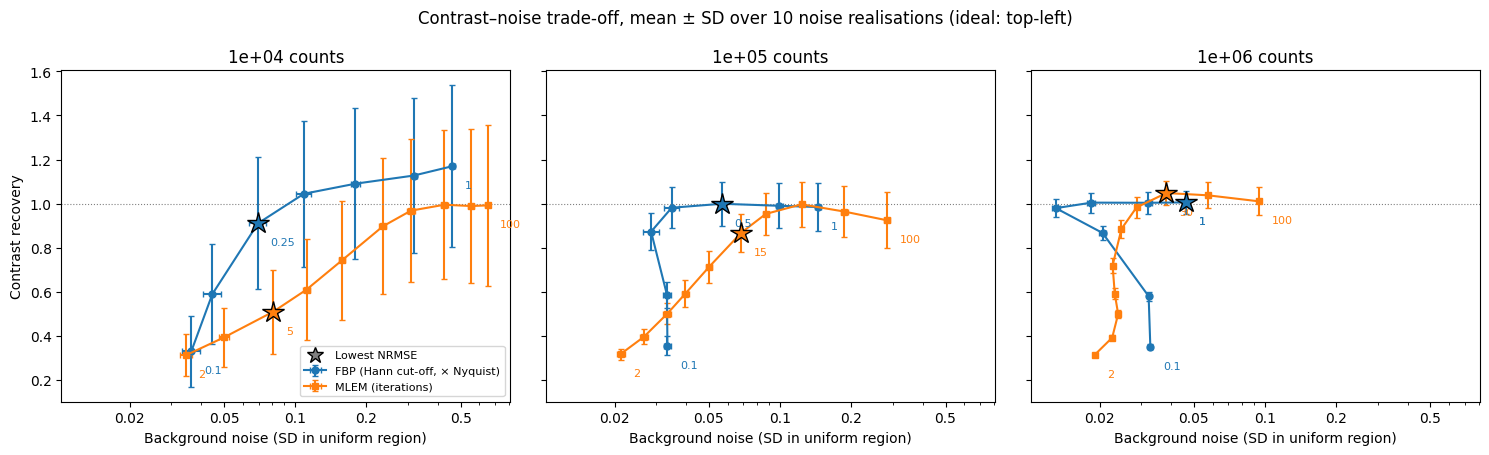

In [42]:
fig, axes = plt.subplots(1, len(COUNT_LEVELS), figsize=(15, 4.6), sharex=True, sharey=True)
styles = {"FBP": dict(color="C0", marker="o", label="FBP (Hann cut-off, × Nyquist)"),
      "MLEM": dict(color="C1", marker="s", label="MLEM (iterations)")}
for ax, c in zip(axes, COUNT_LEVELS):
  for method, st in styles.items():
    s = summary.loc[(c, method)]
    x, y, b = s[("SD_bkg", "mean")], s[("CR", "mean")], best[(c, method)]
    ax.errorbar(x, y, xerr=s[("SD_bkg", "std")], yerr=s[("CR", "std")], capsize=2, lw=1.5, ms=5, **st)
    ax.plot(x[b], y[b], "*", ms=16, color=st["color"], markeredgecolor="k", zorder=5)
    for p in [s.index[0], b, s.index[-1]]:                      # label ends + optimum
      ax.annotate(f"{p:g}", (x[p], y[p]), textcoords="offset points", xytext=(9, -16),
            fontsize=8, color=st["color"])
  ax.axhline(1, color="gray", lw=0.8, ls=":")
  ax.set_xscale("log")
  ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5])
  ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%g"))
  ax.xaxis.set_minor_formatter(mticker.NullFormatter())
  ax.set(title=f"{c:.0e} counts", xlabel="Background noise (SD in uniform region)")
axes[0].set_ylabel("Contrast recovery")
axes[0].plot([], [], "*", ms=12, color="gray", markeredgecolor="k", label="Lowest NRMSE")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(f"Contrast–noise trade-off, mean ± SD over {N_REAL} noise realisations (ideal: top-left)",
      fontsize=12)
plt.tight_layout(); plt.savefig("figures/contrast_noise.png", dpi=150, bbox_inches="tight"); plt.show()

Reconstructions (realisation 0)

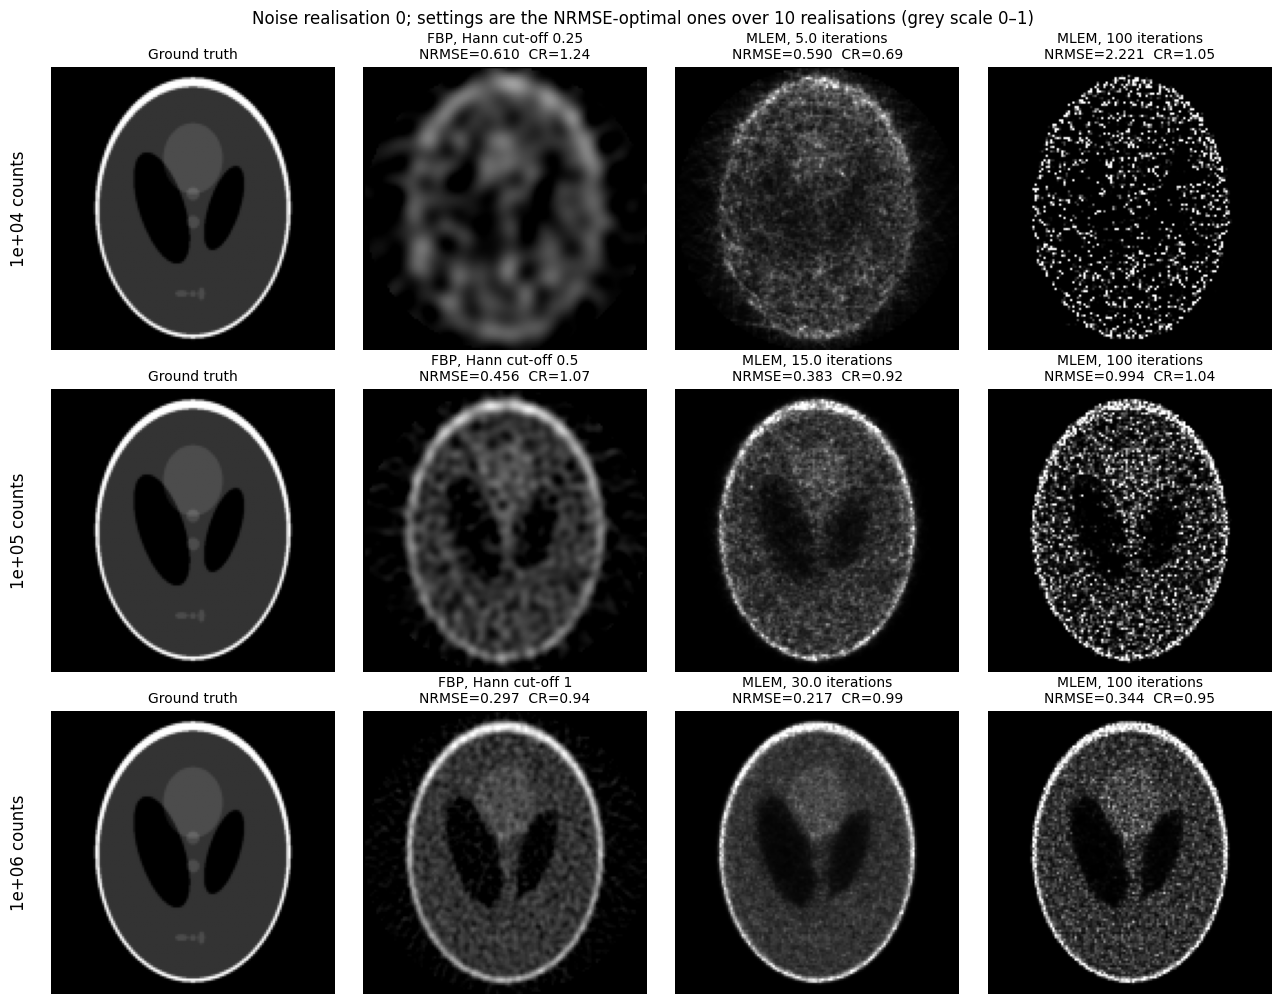

In [43]:
fig, axes = plt.subplots(len(COUNT_LEVELS), 4, figsize=(13, 3.4 * len(COUNT_LEVELS)))
for row, c in zip(axes, COUNT_LEVELS):
  panels = [("Ground truth", None, None),
        (f"FBP, Hann cut-off {best[(c, 'FBP')]:g}", "FBP", best[(c, "FBP")]),
        (f"MLEM, {best[(c, 'MLEM')]} iterations", "MLEM", best[(c, "MLEM")]),
        (f"MLEM, {N_ITER} iterations", "MLEM", N_ITER)]
  for ax, (title, method, p) in zip(row, panels):
    img = phantom if method is None else recon0[(c, method, p)]
    if method is not None:
      m = evaluate(img, phantom, hot, bkg)
      title += f"\nNRMSE={m['NRMSE']:.3f}  CR={m['CR']:.2f}"
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10); ax.axis("off")
  row[0].text(-0.08, 0.5, f"{c:.0e} counts", transform=row[0].transAxes,
        rotation=90, va="center", ha="right", fontsize=12)
fig.suptitle(f"Noise realisation 0; settings are the NRMSE-optimal ones over {N_REAL} realisations "
      "(grey scale 0–1)", fontsize=12)
plt.tight_layout(); plt.savefig("figures/recon_grid.png", dpi=130, bbox_inches="tight"); plt.show()